Usando o exemplo 499

In [1]:
%pip install pandas numpy seaborn tensorflow
%pip install nltk
%pip install lime
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from lime import lime_text

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.feature_extraction.text import TfidfVectorizer



c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('../news_clean_onlly.csv')

In [4]:
df.head()

,Unnamed: 0,title,subject,date,Label,clean_text,label_number,char_count,word_count,avg_word_length
0,0,Donald Trump Sends Out Embarrassing New Year’...,News,"December 31, 2017",Fake,donald trump just couldn t wish all americans ...,0,2620,474,5.527426
1,1,Drunk Bragging Trump Staffer Started Russian ...,News,"December 31, 2017",Fake,house intelligence committee chairman devin nu...,0,1850,304,6.085526
2,2,Sheriff David Clarke Becomes An Internet Joke...,News,"December 30, 2017",Fake,on friday it was revealed that former milwauke...,0,3298,564,5.847518
3,3,Trump Is So Obsessed He Even Has Obama’s Name...,News,"December 29, 2017",Fake,on christmas day donald trump announced that h...,0,2462,423,5.820331
4,4,Pope Francis Just Called Out Donald Trump Dur...,News,"December 25, 2017",Fake,pope francis used his annual christmas day mes...,0,2292,420,5.457143


In [5]:
df.shape

(38516, 10)

<Axes: xlabel='Label', ylabel='count'>

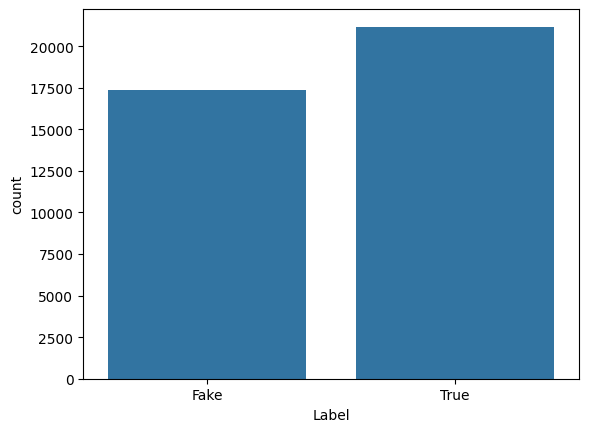

In [6]:
sns.countplot(x='Label', data = df)

**Pré-Processamento**

In [7]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Baixar pacotes necessários do NLTK
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab') # Download the 'punkt_tab' resource

[nltk_data] Downloading package stopwords to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
def preprocess_text(text):
    # Converter para minúsculas
    text = text.lower()

    # Remover caracteres especiais e números
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenização (dividir em palavras)
    tokens = word_tokenize(text)

    # Remover stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]

    # Lematização (reduzir palavras à sua forma base)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Juntar as palavras processadas de volta em uma string
    return " ".join(tokens)

In [9]:
df["clean_text"] = df["title"].apply(preprocess_text)

In [10]:
df.head(5)

,Unnamed: 0,title,subject,date,Label,clean_text,label_number,char_count,word_count,avg_word_length
0,0,Donald Trump Sends Out Embarrassing New Year’...,News,"December 31, 2017",Fake,donald trump sends embarrassing new year eve m...,0,2620,474,5.527426
1,1,Drunk Bragging Trump Staffer Started Russian ...,News,"December 31, 2017",Fake,drunk bragging trump staffer started russian c...,0,1850,304,6.085526
2,2,Sheriff David Clarke Becomes An Internet Joke...,News,"December 30, 2017",Fake,sheriff david clarke becomes internet joke thr...,0,3298,564,5.847518
3,3,Trump Is So Obsessed He Even Has Obama’s Name...,News,"December 29, 2017",Fake,trump obsessed even obamas name coded website ...,0,2462,423,5.820331
4,4,Pope Francis Just Called Out Donald Trump Dur...,News,"December 25, 2017",Fake,pope francis called donald trump christmas speech,0,2292,420,5.457143


<Axes: xlabel='Label', ylabel='count'>

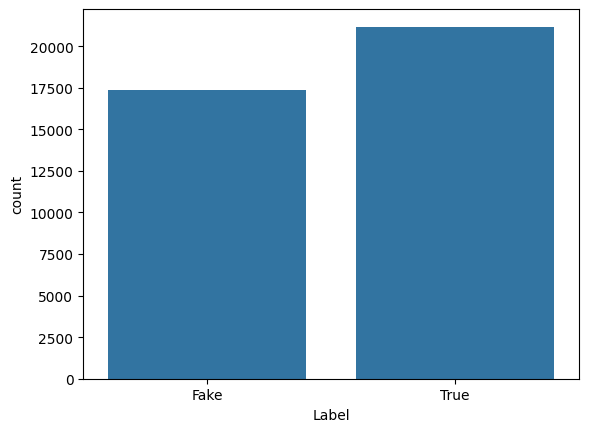

In [12]:
sns.countplot(x="Label", data=df) # validando se mudou as classes

In [14]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Label'])

In [15]:
X = df['clean_text']
y = df['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#, stratify=y

In [16]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words=None
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

**MLP**

In [17]:
model = Sequential()

model.add(Dense(
    256,
    activation='relu',
    input_shape=(X_train_tfidf.shape[1],)
))

model.add(Dropout(0.5))

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dropout(0.3))

model.add(Dense(
    3,
    activation='softmax'
))

c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# Compilar o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use sparse_categorical_crossentropy se y_train for numérico
              metrics=['accuracy'])

In [19]:
# Treinar o modelo
history = model.fit(X_train_tfidf, 
                    y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.1)  # Validação durante o treinamento

Epoch 1/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 52s 56ms/step - accuracy: 0.8983 - loss: 0.2444 - val_accuracy: 0.9445 - val_loss: 0.1412
Epoch 2/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.9543 - loss: 0.1178 - val_accuracy: 0.9409 - val_loss: 0.1457
Epoch 3/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 52s 56ms/step - accuracy: 0.9684 - loss: 0.0820 - val_accuracy: 0.9439 - val_loss: 0.1567
Epoch 4/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 43s 49ms/step - accuracy: 0.9806 - loss: 0.0537 - val_accuracy: 0.9390 - val_loss: 0.1864
Epoch 5/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 43s 49ms/step - accuracy: 0.9884 - loss: 0.0310 - val_accuracy: 0.9390 - val_loss: 0.2298
Epoch 6/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9948 - loss: 0.0158 - val_accuracy: 0.9384 - val_loss: 0.2732
Epoch 7/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 44s 50ms/step - accuracy: 0.9965 - loss: 0.0103 - val_accuracy: 0.9393 - val_loss: 0.3184
Epoch 8/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 83s 52ms/step - accuracy: 0.9982 - loss: 0.0056 - 

**Métricas**

In [20]:
from sklearn.metrics import classification_report

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test_tfidf)
y_pred_classes = np.argmax(y_pred, axis=1)

# Gerar o relatório de classificação
print(classification_report(y_test, y_pred_classes))


241/241 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      3504
           1       0.93      0.95      0.94      4200

    accuracy                           0.93      7704
   macro avg       0.93      0.93      0.93      7704
weighted avg       0.93      0.93      0.93      7704



In [21]:
#acuracia,precisão, recall e f1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    return accuracy, precision, recall, f1
# Calcular as métricas
accuracy, precision, recall, f1 = calculate_metrics(y_test, y_pred_classes)
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Acurácia: 0.9321
Precisão: 0.9321
Recall: 0.9321
F1-Score: 0.9321


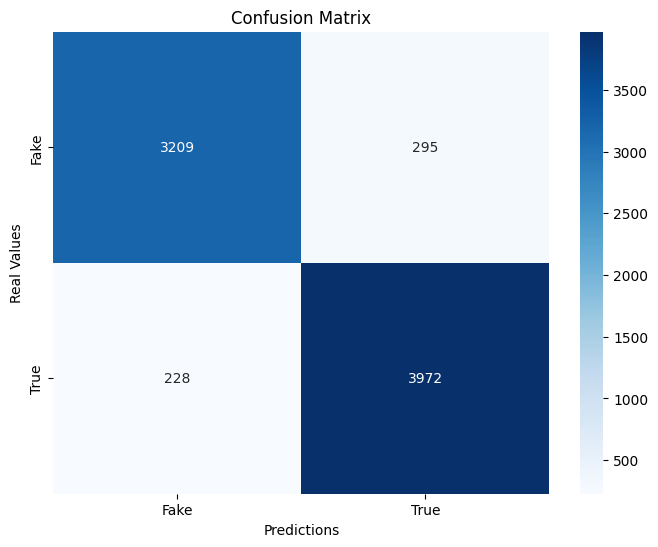

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcular a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Criar o heatmap da matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predictions")
plt.ylabel("Real Values")
plt.title("Confusion Matrix")
plt.show()

**LIME**

In [23]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=le.classes_)

def predict_proba(texts):
    X = tfidf.transform(texts)
    X = X.toarray()
    return model.predict(X, verbose=0)

# Solicita ao usuário o número da linha do exemplo
idx = int(input(f"Digite o número da linha (0 a {len(X_test)-1}): "))
sample_text = X_test.iloc[idx]
sample_label = y_test.iloc[idx]

# Predição da classe para o texto selecionado
sample_tfidf = tfidf.transform([sample_text]).toarray()

pred_probs = model.predict(sample_tfidf, verbose=0)
pred_class_idx = pred_probs.argmax(axis=1)[0]
pred_class_name = le.classes_[pred_class_idx]

print(f"Número da linha no X_test: {idx}")
print(f"Original text:\n{sample_text}")
print(f"Classe real: {le.classes_[sample_label]}")
print(f"Classe predita: {pred_class_name}")

explanation = explainer.explain_instance(
    sample_text,
    predict_proba,
    num_features=10
)

print(explanation.as_list())

Número da linha no X_test: 499
Original text:
party motherland north korea kim herald missile test setback
Classe real: True
Classe predita: True
[(np.str_('north'), 0.00697370339221333), (np.str_('missile'), 0.006565082737024031), (np.str_('kim'), 0.006468965411066457), (np.str_('setback'), 0.006308772346991201), (np.str_('korea'), 0.005641898491612921), (np.str_('test'), 0.004917455607222098), (np.str_('motherland'), -0.0012084706794922772), (np.str_('party'), 0.0004586060381322167), (np.str_('herald'), -0.00031751549104707435)]


In [24]:
# Obtém as palavras mais importantes e seus pesos
lime_features = explanation.as_list()

# Exibe cada palavra com seu impacto na predição
print("Palavras mais importantes e seus pesos:")
for word, weight in lime_features:
    print(f"{word}: {weight:.4f}")

Palavras mais importantes e seus pesos:
north: 0.0070
missile: 0.0066
kim: 0.0065
setback: 0.0063
korea: 0.0056
test: 0.0049
motherland: -0.0012
party: 0.0005
herald: -0.0003


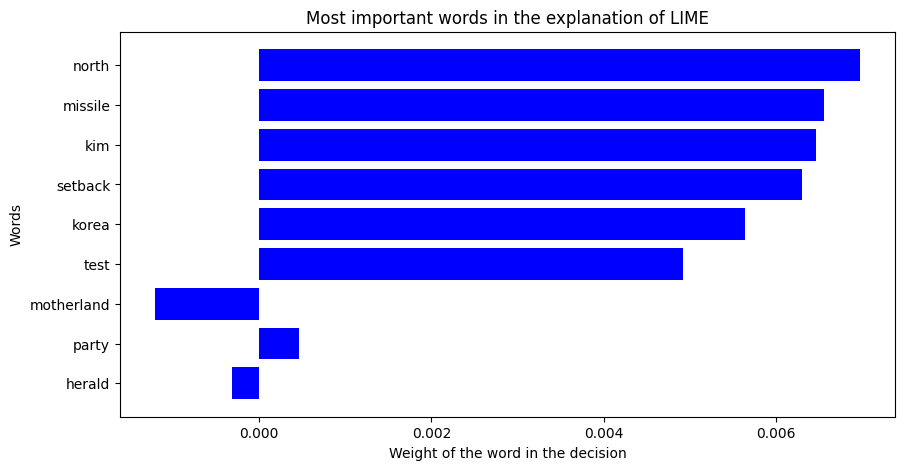

In [25]:
# Separar palavras e pesos
words, weights = zip(*lime_features)

# Criar gráfico de barras
plt.figure(figsize=(10, 5))
plt.barh(words, weights, color="blue")
plt.xlabel("Weight of the word in the decision")
plt.ylabel("Words")
plt.title("Most important words in the explanation of LIME")
plt.gca().invert_yaxis()  # Inverter para mostrar a palavra mais importante no topo
plt.show()

In [26]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Imprimir as palavras e pesos
for word, weight in words_weights:
    print(f"{word}: {weight}")

north: 0.00697370339221333
missile: 0.006565082737024031
kim: 0.006468965411066457
setback: 0.006308772346991201
korea: 0.005641898491612921
test: 0.004917455607222098
motherland: -0.0012084706794922772
party: 0.0004586060381322167
herald: -0.00031751549104707435


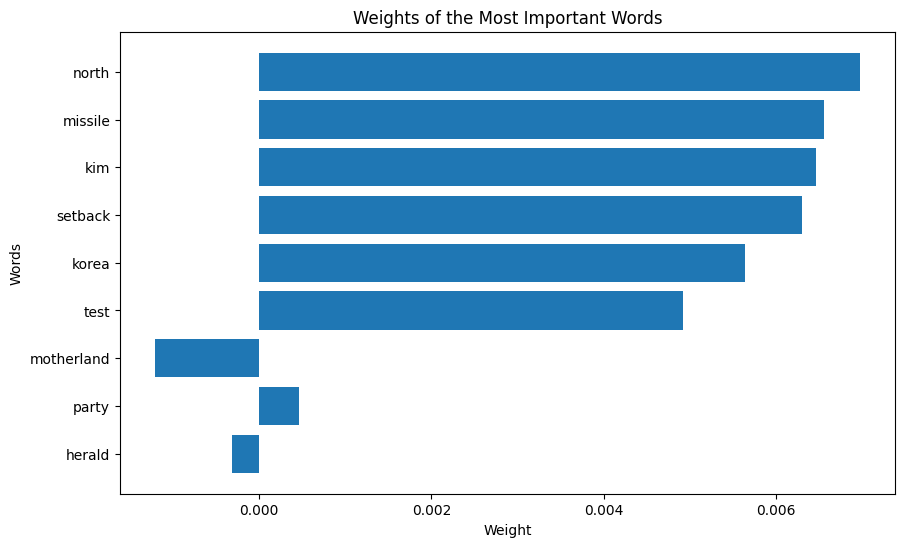

In [27]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Separar palavras e pesos em listas separadas
words = [word for word, weight in words_weights]
weights = [weight for word, weight in words_weights]

# Criar o gráfico de barras horizontais
plt.figure(figsize=(10, 6))  # Ajustar o tamanho da figura, se necessário
plt.barh(words, weights)
plt.xlabel("Weight")
plt.ylabel("Words")
plt.title("Weights of the Most Important Words")
plt.gca().invert_yaxis()  # Inverter o eixo y para que as palavras mais importantes estejam no topo
plt.show()

**Attention Viz**

In [28]:
le.classes_

array(['Fake', 'True'], dtype=object)

In [29]:
# Verificar a arquitetura do MLP

model.summary()

print("\n====================================")

for i, layer in enumerate(model.layers):
    print(f"{i} -> {layer.name} ({layer.__class__.__name__})")

    pesos = layer.get_weights()

    if len(pesos) > 0:
        print("   Pesos:", pesos[0].shape)
        print("   Bias :", pesos[1].shape)

print("====================================")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     1,280,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,940,619 (15.03 MB)

 Trainable params: 1,313,539 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,627,080 (10.02 MB)


0 -> dense (Dense)
   Pesos: (5000, 256)
   Bias : (256,)
1 -> dropout (Dropout)
2 -> dense_1 (Dense)
   Pesos: (256, 128)
   Bias : (128,)
3 -> dropout_1 (Dropout)
4 -> dense_2 (Dense)
   Pesos: (128, 3)
   Bias : (3,)


Texto usado na explicação:
party motherland north korea kim herald missile test setback

Classe prevista: 1
Probabilidades: [5.6456356e-10 1.0000000e+00 4.0771315e-17]
Camadas Dense encontradas:
0 dense (5000, 256)
1 dense_1 (256, 128)
2 dense_2 (128, 3)

Dimensões:
W1: (5000, 256)
W2: (256, 128)
W3: (128, 3)
Global: (5000, 3)
Importance: (5000,)
TFIDF: (5000,)
Número de palavras: 7
   Feature     TFIDF     Weight  Contribution
5  setback  0.503664  37.604797     18.940188
3    north  0.280306  35.625252      9.985960
2  missile  0.375398  23.051422      8.653460
6     test  0.388235  12.829311      4.980789
1    korea  0.289278  16.974310      4.910302
0      kim  0.444399   9.554590      4.246048
4    party  0.308105   4.178017      1.287268


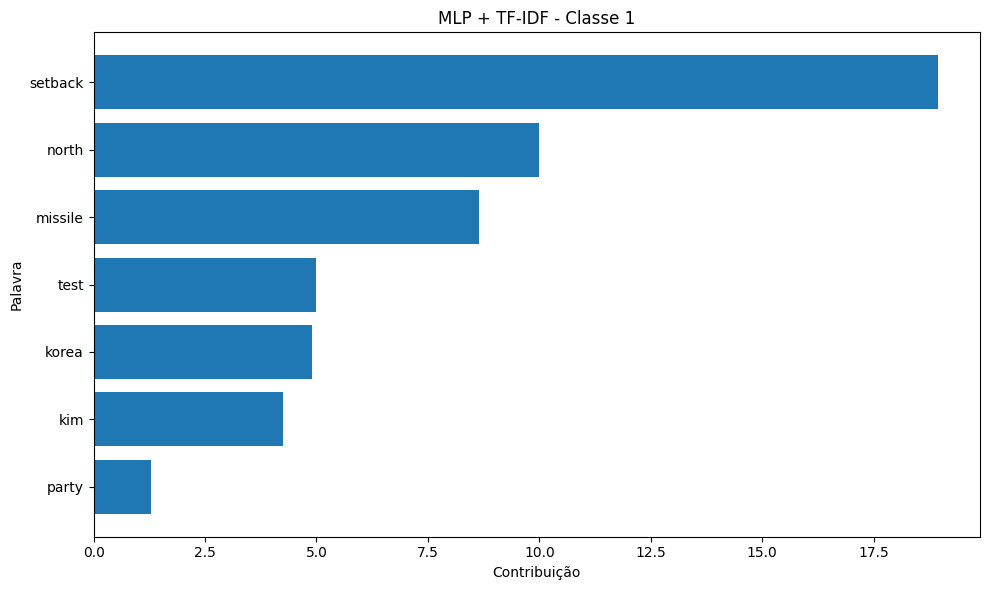

In [30]:
# =====================================================
# MESMO EXEMPLO UTILIZADO NO LIME
# =====================================================

lime_idx = 499

sample_text = X_test.iloc[lime_idx]

print("Texto usado na explicação:")
print(sample_text)

# =====================================================
# ETAPA 1: PREVISÃO DO MODELO
# =====================================================

sample_tfidf = X_test_tfidf[lime_idx:lime_idx+1]

prediction = model.predict(sample_tfidf, verbose=0)

predicted_class_index = np.argmax(prediction[0])

print(f"\nClasse prevista: {predicted_class_index}")
print("Probabilidades:", prediction[0])

# =====================================================
# ETAPA 2: IMPORTÂNCIA GLOBAL DAS FEATURES
# =====================================================

feature_names = tfidf.get_feature_names_out()

# Recuperar apenas as camadas Dense
dense_layers = [layer for layer in model.layers if "Dense" in layer.__class__.__name__]

print("Camadas Dense encontradas:")
for i, layer in enumerate(dense_layers):
    print(i, layer.name, layer.get_weights()[0].shape)

# Matrizes de pesos
W1 = dense_layers[0].get_weights()[0]
W2 = dense_layers[1].get_weights()[0]
W3 = dense_layers[2].get_weights()[0]

print("\nDimensões:")
print("W1:", W1.shape)
print("W2:", W2.shape)
print("W3:", W3.shape)

# Propagação linear dos pesos
global_weights = W1 @ W2 @ W3

print("Global:", global_weights.shape)

# Importância da classe prevista
global_importance = global_weights[:, predicted_class_index]

print("Importance:", global_importance.shape)

# =====================================================
# ETAPA 3: PALAVRAS PRESENTES NO TEXTO
# =====================================================

tfidf_vector = sample_tfidf.toarray().flatten()

print("TFIDF:", tfidf_vector.shape)

indices = np.where(tfidf_vector > 0)[0]

print("Número de palavras:", len(indices))

palavras = feature_names[indices]

pesos = global_importance[indices]

contribuicao = tfidf_vector[indices] * pesos

importancias = pd.DataFrame({
    "Feature": palavras,
    "TFIDF": tfidf_vector[indices],
    "Weight": pesos,
    "Contribution": contribuicao
})

importancias = importancias.sort_values(
    by="Contribution",
    ascending=False
)

print(importancias.head(20))

# =====================================================
# ETAPA 4: VISUALIZAÇÃO
# =====================================================

top = importancias.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"],
    top["Contribution"]
)

plt.xlabel("Contribuição")
plt.ylabel("Palavra")
plt.title(f"MLP + TF-IDF - Classe {predicted_class_index}")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

Shapley

Classe prevista: 1


  0%|          | 0/1 [00:00<?, ?it/s]c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=1.004e-01, with an active set of 6 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
100%|██████████| 1/1 [00:06<00:00,  6.91s/it]
c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\plots\_force_matplotlib.py:325: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(min_x, max_x)


Palavras: ['test' 'setback' 'party' 'north' 'missile' 'korea' 'kim']
TF-IDF: [0.38823511 0.50366415 0.30810498 0.28030566 0.3753981  0.28927847
 0.44439871]
SHAP: [0. 0. 0. 0. 0. 0. 0.]


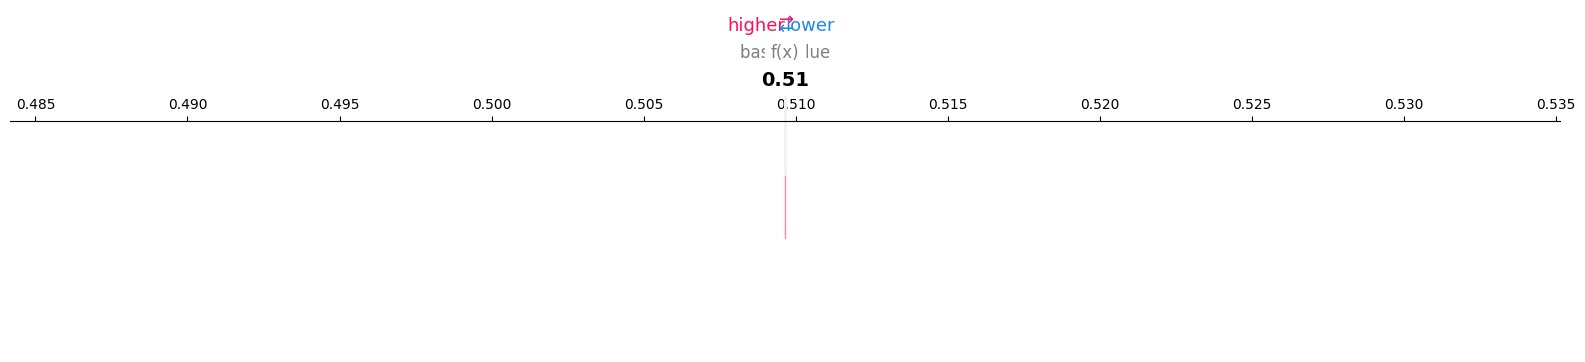

In [31]:
# =====================================================
# Mesma instância utilizada no LIME
# =====================================================

lime_idx = 499

X_instance = X_test_tfidf[lime_idx:lime_idx+1]

# Se estiver usando matriz esparsa
if not isinstance(X_instance, np.ndarray):
    X_instance = X_instance.toarray()

# =====================================================
# Classe prevista
# =====================================================

pred_probs = model.predict(X_instance, verbose=0)

pred_class_idx = np.argmax(pred_probs, axis=1)[0]

print("Classe prevista:", pred_class_idx)

# =====================================================
# Função do SHAP
# =====================================================

def predict_fn(x):
    return model.predict(x, verbose=0)[:, pred_class_idx]

# =====================================================
# Background
# =====================================================

background_size = 100

if isinstance(X_train_tfidf, np.ndarray):
    background = X_train_tfidf[
        np.random.choice(
            X_train_tfidf.shape[0],
            min(background_size, X_train_tfidf.shape[0]),
            replace=False
        )
    ]
else:
    background = X_train_tfidf[
        np.random.choice(
            X_train_tfidf.shape[0],
            min(background_size, X_train_tfidf.shape[0]),
            replace=False
        )
    ].toarray()

# =====================================================
# Kernel SHAP
# =====================================================

explainer = shap.KernelExplainer(
    predict_fn,
    background
)

shap_values = explainer.shap_values(
    X_instance,
    nsamples=100
)

# Compatibilidade entre versões do SHAP
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values).reshape(-1)

expected_value = explainer.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(np.array(expected_value).reshape(-1)[0])

# =====================================================
# Recuperar palavras presentes no documento
# =====================================================

feature_names = np.array(tfidf.get_feature_names_out())

tfidf_vector = X_instance.reshape(-1)

indices = np.where(tfidf_vector > 0)[0]

words = feature_names[indices]

values = shap_values[indices]

tfidf_values = tfidf_vector[indices]

# =====================================================
# Ordenar por impacto absoluto
# =====================================================

order = np.argsort(np.abs(values))[::-1]

top_k = 15

order = order[:top_k]

words = words[order]

values = values[order]

tfidf_values = tfidf_values[order]

formatted_labels = [
    f"{w} ({t:.3f})"
    for w, t in zip(words, tfidf_values)
]

# =====================================================
# Force Plot
# =====================================================

print("Palavras:", words)
print("TF-IDF:", tfidf_values)
print("SHAP:", values)

shap.force_plot(
    base_value=expected_value,
    shap_values=values,
    features=tfidf_values,
    feature_names=formatted_labels,
    matplotlib=True
)